In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *
from datetime import datetime, date, timedelta, time

In [5]:
# https://nbviewer.org/github/mayabenowitz/Hedgecraft/blob/master/notebooks/Hedgecraft.ipynb

In [6]:
import pandas as pd
import numpy as np

#silence warnings
import warnings
warnings.filterwarnings("ignore")

#reads the csv file into pandas DataFrame
BASE_DATA_DIR = "D:/Code/tgraphportfolio/rsrc/data/eod"

df2 = pd.read_csv(f"{BASE_DATA_DIR}/all_stocks_2006-01-01_to_2018-01-01.csv")
df = pd.read_csv(f"{BASE_DATA_DIR}/FTSE100_20070102_20190211.csv")

In [7]:
df['Date'] = pd.to_datetime(df['Index'])

In [8]:

#imports the dcor module to calculate distance correlation
import dcor

#function to compute the distance correlation (dcor) matrix from a DataFrame and output a DataFrame 
#of dcor values.
def df_distance_correlation(df_train, stocks):
    #initializes an empty DataFrame
    df_train_dcor = pd.DataFrame(index=stocks, columns=stocks)
    #initialzes a counter at zero
    k=0
    #iterates over the time series of each stock
    for i in stocks:
        #stores the ith time series as a vector
        v_i = df_train.loc[:, i].values
        #iterates over the time series of each stock subect to the counter k
        for j in stocks[k:]: # only does what it needs to (k:)
            #stores the jth time series as a vector
            v_j = df_train.loc[:, j].values
            
            vi_vj = np.column_stack((v_i,v_j))
            vi_vj = vi_vj[~np.isnan(vi_vj).any(axis=1)]

            #computes the dcor coefficient between the ith and jth vectors
            dcor_val = dcor.distance_correlation(vi_vj[:,0], vi_vj[:,1])            #appends the dcor value at every ij entry of the empty DataFrame
            df_train_dcor.at[i,j] = dcor_val
            #appends the dcor value at every ji entry of the empty DataFrame
            df_train_dcor.at[j,i] = dcor_val
        #increments counter by 1
        k+=1    
    #returns a DataFrame of dcor values for every pair of stocks
    return df_train_dcor

In [9]:
# dff will be the df2
dff = df2[:]
dff['Date'] = pd.to_datetime(dff['Date']).dt.date


In [10]:
(dff['Date'].min(),dff['Date'].max())

(datetime.date(2006, 1, 3), datetime.date(2017, 12, 29))

In [11]:
#creates a DataFrame for each time-series (see In [11])
cutoff_date = date(2012, 1, 1)
df_train = dff.query("Date < @cutoff_date")
df_train = df_train.dropna()
df_train['IntraDelta'] = df_train['Close'] - df_train['Open']

In [12]:
def pivot_to_wide_format(df, date_col='Date', name_col='Name', value_col='Close'):
    """
    Pivot a dataframe from long to wide format.
    
    Parameters:
    -----------
    df : DataFrame
        Input dataframe with Date, Name, and value columns
    date_col : str, default 'Date'
        Name of the date column
    name_col : str, default 'Name'
        Name of the column containing names to become column headers
    value_col : str, default 'Close'
        Name of the column containing values to pivot
    
    Returns:
    --------
    DataFrame
        Pivoted dataframe with Date as rows, Name values as columns, sorted alphabetically
    """
    # Pivot to wide format: Date as rows, Name as columns, values as specified
    df_pivoted = df.pivot(index=date_col, columns=name_col, values=value_col)
    # Sort column names (Name values) alphabetically
    df_pivoted = df_pivoted.reindex(sorted(df_pivoted.columns), axis=1)
    # Reset index to make Date a column
    df_pivoted = df_pivoted.reset_index()
    return df_pivoted

# Apply the function to df_train
df_train_close = pivot_to_wide_format(df_train, value_col='Close')
df_train_open = pivot_to_wide_format(df_train, value_col='Open')
df_train_high = pivot_to_wide_format(df_train, value_col='High')
df_train_low = pivot_to_wide_format(df_train, value_col='Low')
df_train_intradelta = pivot_to_wide_format(df_train, value_col='IntraDelta')

#makes a copy of the traning dataset
# df_train_close_copy = df_train_close.copy()

In [13]:
df_train_high_dcor = df_distance_correlation( df_train_high, stocks = [x for x in df_train_high.columns if x!='Date'] )
df_train_low_dcor = df_distance_correlation( df_train_low, stocks = [x for x in df_train_low.columns if x!='Date'] )
df_train_open_dcor = df_distance_correlation( df_train_open, stocks = [x for x in df_train_open.columns if x!='Date'] )
df_train_close_dcor = df_distance_correlation( df_train_close, stocks = [x for x in df_train_close.columns if x!='Date'] )
df_train_intradelta_dcor = df_distance_correlation( df_train_intradelta, stocks = [x for x in df_train_intradelta.columns if x!='Date'] )

In [46]:
#imports the NetworkX module
import networkx as nx

# takes in a pre-processed dataframe and returns a time-series correlation
# network with pairwise distance correlation values as the edges
def build_corr_nx(df_train, independent_threshold=0.33):
    # converts the distance correlation dataframe to a numpy matrix with dtype float
    cor_matrix = df_train.values.astype('float')
    # Since dcor ranges between 0 and 1, (0 corresponding to independence and 1
    # corresponding to dependence), 1 - cor_matrix results in values closer to 0
    # indicating a higher degree of dependence where values close to 1 indicate a lower degree of 
    # dependence. This will result in a network with nodes in close proximity reflecting the similarity
    # of their respective time-series and vice versa.
    sim_matrix = 1 - cor_matrix
    # transforms the similarity matrix into a graph
    G = nx.from_numpy_array(sim_matrix)
    # extracts the indices (i.e., the stock names from the dataframe)
    stock_names = df_train.index.values
    # relabels the nodes of the network with the stock names
    G = nx.relabel_nodes(G, lambda x: stock_names[x])
    # assigns the edges of the network weights (i.e., the dcor values)
    G.edges(data=True)
    # copies G
    ## we need this to delete edges or othwerwise modify G
    H = G.copy()
    # iterates over the edges of H (the u-v pairs) and the weights (wt)
    for (u, v, wt) in G.edges.data('weight'):
        # selects edges with dcor values less than or equal to 0.33
        if wt >= 1 - independent_threshold:  
            # removes the edges 
            H.remove_edge(u, v)
        # selects self-edges
        if u == v:
            # removes the self-edges
            H.remove_edge(u, v)
    # returns the final stock correlation network            
    return H

In [15]:
# df_train_high_dcor

In [16]:
H_close = build_corr_nx(df_train_close_dcor)
H_open = build_corr_nx(df_train_open_dcor)
H_close_diff = build_corr_nx(df_train_intradelta_dcor)
H_high = build_corr_nx(df_train_high_dcor)
H_low = build_corr_nx(df_train_low_dcor)

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
# def plot_corr_nx_w_title(H, df_train, type = "Close"):
#     title_str = f"Distance Correlation Network of the Daily {type} ({df_train['Date'].min().strftime('%Y-%m-%d')}-{df_train['Date'].max().strftime('%Y-%m-%d')})"
#     plt_corr_nx(H, title=title_str)

# function to display the network from the distance correlation matrix
def plot_corr_nx(H, title):

    # creates a set of tuples: the edges of G and their corresponding weights
    edges, weights = zip(*nx.get_edge_attributes(H, "weight").items())

    pos = nx.kamada_kawai_layout(H)

    with sns.axes_style('whitegrid'):
        # figure size and style
        plt.figure(figsize=(12, 9))
        plt.title(title, size=16)

        # computes the degree (number of connections) of each node
        deg = H.degree

        # list of node names
        nodelist = []
        # list of node sizes
        node_sizes = []

        # iterates over deg and appends the node names and degrees
        for n, d in deg:
            nodelist.append(n)
            node_sizes.append(d)

        # draw nodes
        nx.draw_networkx_nodes(
            H,
            pos,
            node_color="#DA70D6",
            nodelist=nodelist,
            node_size=np.power(node_sizes, 2.33),
            alpha=0.8,
            # font_weight="bold",
        )

        # node label styles
        nx.draw_networkx_labels(H, pos, font_size=13, font_family="sans-serif", font_weight='bold')

        # color map
        cmap = sns.cubehelix_palette(3, as_cmap=True, reverse=True)

        # draw edges
        nx.draw_networkx_edges(
            H,
            pos,
            edgelist=edges,
            style="solid",
            edge_color=weights,
            edge_cmap=cmap,
            edge_vmin=min(weights),
            edge_vmax=max(weights),
        )

        # builds a colorbar
        sm = plt.cm.ScalarMappable(
            cmap=cmap, 
            norm=plt.Normalize(vmin=min(weights), 
            vmax=max(weights))
        )
        sm._A = []
        plt.colorbar(sm)

        # displays network without axes
        plt.axis("off")

#silence warnings   
import warnings
warnings.filterwarnings("ignore")


In [31]:

def plot_corr_nx(H, title="Distance Correlation Network"):
    """
    Plot a networkx graph with edge colors based on weights.
    Fixed version with proper colorbar axes handling.
    
    Parameters:
    -----------
    H : networkx.Graph
        Graph to plot
    title : str, default "Distance Correlation Network"
        Title for the plot
    """
    # Create figure and axes explicitly
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Get edge weights
    weights = [H[u][v]['weight'] for u, v in H.edges()]
    
    # Set up colormap
    cmap = plt.cm.viridis
    
    # Draw the graph
    # This draws the network with the Kamada-Kawai path-length cost-function.
    # Nodes are positioned by treating the network as a physical ball-and-spring system. The locations
    # of the nodes are such that the total energy of the system is minimized.
    pos = nx.kamada_kawai_layout(H)
    # pos = nx.spring_layout(H, k=1, iterations=50)
    edges = nx.draw_networkx_edges(H, pos, edge_color=weights, edge_cmap=cmap, 
                                   width=2, alpha=0.6, ax=ax)
    nx.draw_networkx_nodes(H, pos, node_color='lightblue', node_size=500, ax=ax)
    nx.draw_networkx_labels(H, pos, font_size=8, ax=ax)
    
    # Create ScalarMappable for colorbar
    sm = plt.cm.ScalarMappable(
        cmap=cmap, 
        norm=plt.Normalize(vmin=min(weights), vmax=max(weights))
    )
    sm.set_array([])  # Fixed: use set_array instead of _A
    
    # Add colorbar with explicit axes reference
    plt.colorbar(sm, ax=ax)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.axis("off")
    plt.tight_layout()
    plt.show()

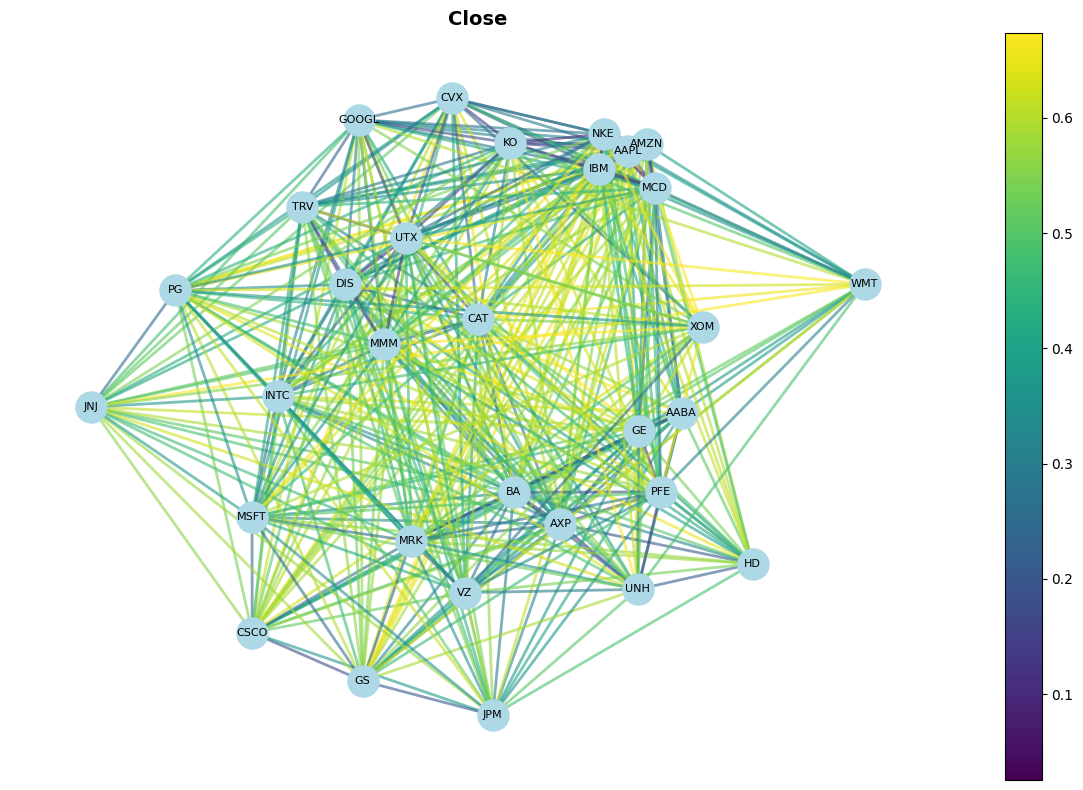

In [32]:
plot_corr_nx(H_close, 'Close')

In [ ]:
import gravis as gv
import matplotlib.pyplot as plt

def plot_corr_gravis(H):
    """
    Plot a networkx graph using gravis with edge colors based on weights.
    
    Parameters:
    -----------
    H : networkx.Graph
        Graph to plot
    """
    # Get edge weights for color mapping
    weights = [H[u][v]['weight'] for u, v in H.edges()]
    min_weight = min(weights)
    max_weight = max(weights)
    
    # Normalize weights to 0-1 range for color mapping
    def normalize_weight(w):
        if max_weight == min_weight:
            return 0.5
        return (w - min_weight) / (max_weight - min_weight)
    
    # Create a copy of the graph with normalized weights and colors
    G = H.copy()
    
    # Add color attributes to edges based on normalized weights
    # Using viridis-like color scheme (blue to yellow)
    for u, v in G.edges():
        weight = G[u][v]['weight']
        norm_weight = normalize_weight(weight)
        
        # Convert normalized weight to RGB color (viridis-like: blue to yellow)
        # Using a simple color interpolation
        if norm_weight < 0.5:
            # Blue to cyan
            r = 0
            g = int(norm_weight * 2 * 255)
            b = 255
        else:
            # Cyan to yellow
            r = int((norm_weight - 0.5) * 2 * 255)
            g = 255
            b = int(255 - (norm_weight - 0.5) * 2 * 255)
        
        # Convert to hex color
        color = f"#{r:02x}{g:02x}{b:02x}"
        G[u][v]['color'] = color
        G[u][v]['width'] = 2 + norm_weight * 3  # Width based on weight
    
    # Set node attributes
    for node in G.nodes():
        G.nodes[node]['size'] = 20
        G.nodes[node]['color'] = '#ADD8E6'  # lightblue
    
    # Create visualization with gravis
    fig = gv.d3(
        G,
        graph_height=400,
        details_height=100,
        show_details=True,
        show_details_toggle_button=True,
        show_menu=True,
        show_menu_toggle_button=True,
        show_node=True,        
        # title=title,
        show_edge_label=False,
        show_node_label=True,
        # node_label_size=12,
        node_hover_neighborhood=True,
        node_hover_tooltip=True,
        show_node_image=True,
        show_edge=True,
        edge_size_factor=1.0,
        edge_size_data_source='size',
        use_edge_size_normalization=False,
        edge_size_normalization_min=0.2,
        edge_size_normalization_max=5.0,
        edge_curvature=0.0,
        edge_hover_tooltip=True,            
        # edge_width_data_source='width',
        # edge_color_data_source='color',
        # node_size_data_source='size',
        # node_color_data_source='color',
        use_node_size_normalization=False,
        # use_edge_size_normalization=False,
        # height=800,
        # width=1200
    )
    
    return fig


In [39]:
plot_corr_gravis(H_close)

In [43]:
# function to visualize the degree distribution
def hist_plot(network, title, bins, xticks):
    
    # extracts the degrees of each vertex and stores them as a list
    deg_list = list(dict(network.degree).values())
    # sets local style
    with plt.style.context('fivethirtyeight'):
        # initializes a figure
        plt.figure(figsize=(9,6))
        # plots a pretty degree histogram with a kernel density estimator
        sns.distplot(
            deg_list,  
            kde=True,
            bins = bins,
            color='darksalmon',
            hist_kws={'alpha': 0.7}
        );
        # turns the grid off
        plt.grid(True)
        # controls the number and spacing of xticks and yticks
        plt.xticks(xticks, size=11)
        plt.yticks(size=11)
        # removes the figure spines
        #  sns.despine(left=True, right=True, bottom=True, top=True)
        # labels the y and x axis
        #  plt.ylabel("Probability", size=15)
        plt.xlabel("Number of Connections", size=15)
        # sets the title
        plt.title(title, size=20);
        # draws a vertical line where the mean is
        plt.axvline(sum(deg_list)/len(deg_list), 
                    color='darkorchid', 
                    linewidth=3, 
                    linestyle='--', 
                    label='Mean = {:2.0f}'.format(sum(deg_list)/len(deg_list))
        )

        # turns the legend on
        plt.legend(loc=0, fontsize=12)

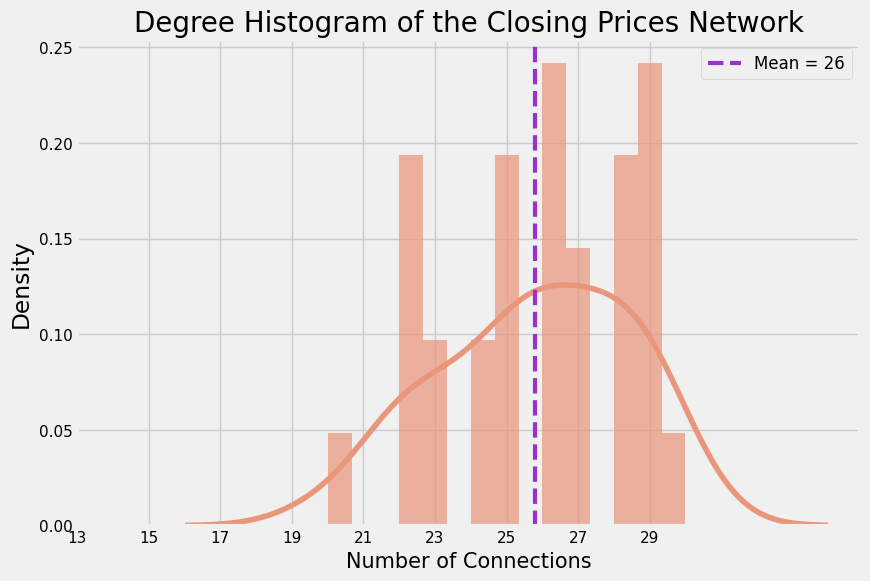

In [ ]:
# plots the degree histogram of the closing prices network
hist_plot(
    H_close, 
    'Degree Histogram of the Closing Prices Network', 
    bins=15, 
    xticks=range(13, 30, 2)
)


In [ ]:
H_close.degree

DegreeView({'AABA': 22, 'AAPL': 25, 'AMZN': 25, 'AXP': 29, 'BA': 29, 'CAT': 30, 'CSCO': 27, 'CVX': 23, 'DIS': 29, 'GE': 26, 'GOOGL': 25, 'GS': 27, 'HD': 22, 'IBM': 27, 'INTC': 28, 'JNJ': 23, 'JPM': 22, 'KO': 24, 'MCD': 26, 'MMM': 28, 'MRK': 28, 'MSFT': 26, 'NKE': 26, 'PFE': 28, 'PG': 29, 'TRV': 26, 'UNH': 25, 'UTX': 29, 'VZ': 24, 'WMT': 20, 'XOM': 22})